# Стоит ли чат на месте?
### часть 1. эргодичность

Проверю с одной стороны эволюцию кластеров, долей тем, и их динамику, что происходит на этом уровне

Проверю с другой стороны, есть ли какая либо динамика в чате, если аггрегированное среднее статично
+проверка нескольких гипотез

Импорты

In [1]:
import os
while not os.path.isdir("chats"): os.chdir("..")
import numpy as np, pandas as pd, seaborn as sns



In [ ]:
df = pd.read_csv("chats/physics/df.csv", parse_dates=["ts"])
df

In [4]:
df = df[~df["is_bot"]].reset_index(drop=True)

In [ ]:
cats = sorted(df['mega'].unique())
K = len(cats)

print(len(df), "сообщений,", K, "тем")

117775 сообщений, 7 тем


In [8]:

df["k"] = df.mega.map({c: i for i, c in enumerate(cats)}) 
codes = df["k"].to_numpy()

In [9]:
df.iloc[0]

unit_id                                        0
author_id                         u0001
ts                           2023-02-04 20:57:32
day                                   2023-02-04
session                                        1
reply_to_unit                                 -1
mega                                Разбор задач
subtopic         Апелляция по конкретным задачам
subtopic_id                                   48
content_kind                                text
speech_act                             statement
is_bot                                     False
is_reply                                   False
year                                        2023
tenure_days                                  0.0
pos                                            0
k                                              6
Name: 0, dtype: object

## о чём чат

<Axes: ylabel='mega'>

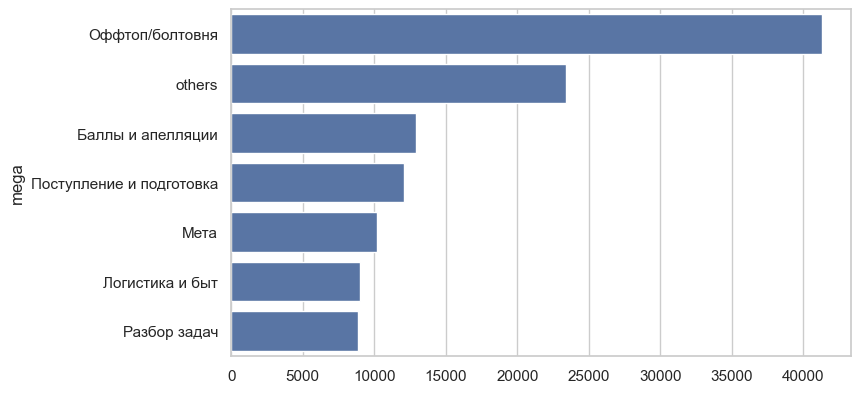

In [11]:
vc = df["mega"].value_counts()
sns.barplot(x=vc.values, y=vc.index)

## правда ли ничего не меняется
темы по годам
логично что если флуктуация тем (доля) то динамика есть

<Axes: xlabel='year', ylabel='доля'>

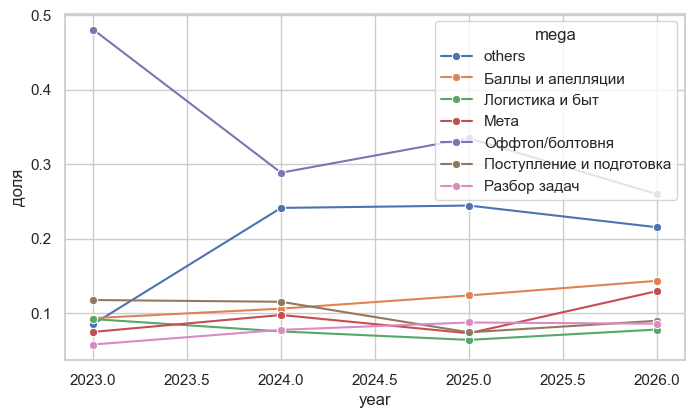

In [12]:
# доля каждой темы по годам
g = df[df.year.isin([2023, 2024, 2025, 2026])]
g = g.groupby(["year", "mega"]).size().reset_index(name="n")
g["доля"] = g["n"] / g.groupby("year")["n"].transform("sum")
sns.lineplot(data=g, x="year", y="доля", hue="mega", marker="o")

In [ ]:
#почти горизонтально - практически статика с этой стороны
#но можно чекнуть еще гляну не на весь год, а на короткие куски

## короткие окна

самая частая тема и ее доля не по годам, а по кускам подряд по 1500 сообщений.

<Axes: >

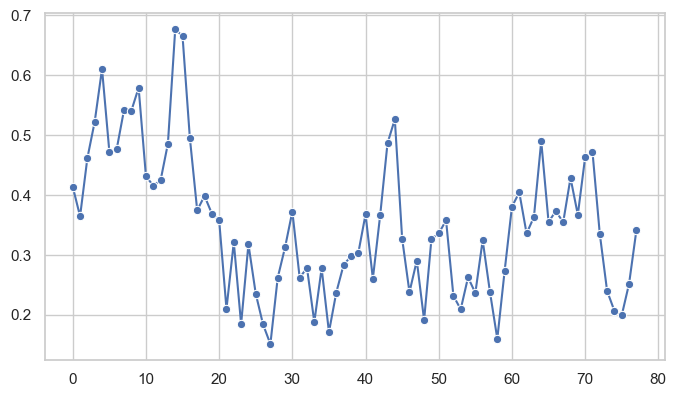

In [13]:
top = vc.index[0]
kt = cats.index(top)     # номер самой частой темы

win = 1500
n = len(codes) // win
share = []
for w in range(n):
    window = codes[w*win : (w+1)*win]
    share.append((window == kt).mean())    # доля топ-темы в окне
sns.lineplot(x=range(n), y=share, marker="o")

In [14]:
#скачет в разы, а не горизонтально!!!!!!! значит годовая константа - усреднение движения

## а сколько эти движения ДОЛЖНЫ быть

надо с чем-то сравнить. рассмотрим самую простую  модель - тема i выпадает независимо с
вероятностью p_i. тогда у доли в окне из n штук дисперсия = E(x^2) - E(x)^2 = p - p^2. 

разделим на n: p(1-p)/n - ПРЕДПОЛОЖЕНИЕ: это нижнаяя оценка на шум, ниже него доля колебаться не будет.

делим реальную дисперсию на этот пол => индекс дисперсии D. тогда D=1 случайность, D>1 - можно интерпретировать как устойчивые волны,
D<1 есть взаимосвязь сильная

<Axes: >

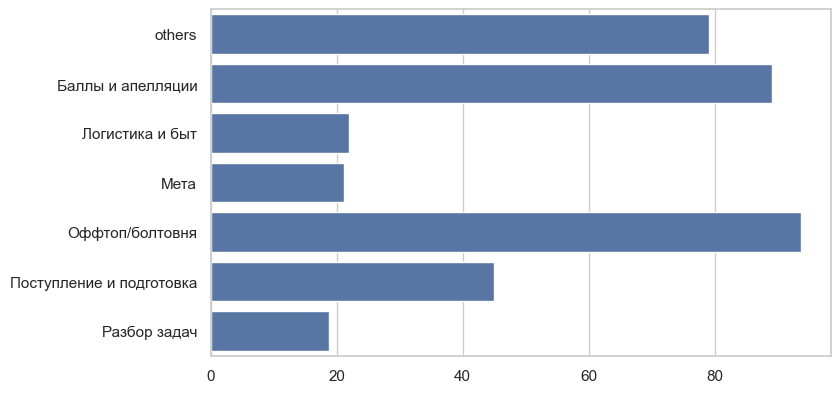

In [17]:
# доли всех тем по окнам
d = []
for w in range(n):
    window = codes[w*win : (w+1)*win]
    d.append([(window == k).mean() for k in range(K)])
d = np.array(d)

p = d.mean(0)
D = d.var(0) / (p * (1 - p) / win)
sns.barplot(x=D, y=cats)

In [ ]:
#все D много больше 1, ни одной меньше => волны есть 
# (реальная дисперсия больше бернулевской теоретической)

## вдруг средняя стоит потому что все одинаковые

ГИПОТЕЗА: Статистически люди имеют одинаковый или очень близкий профиль активности (как это мерить?) 
Тогда можно предположить что система эргодична - траектория элемента похожа на среднюю траекторию системы!!!!!


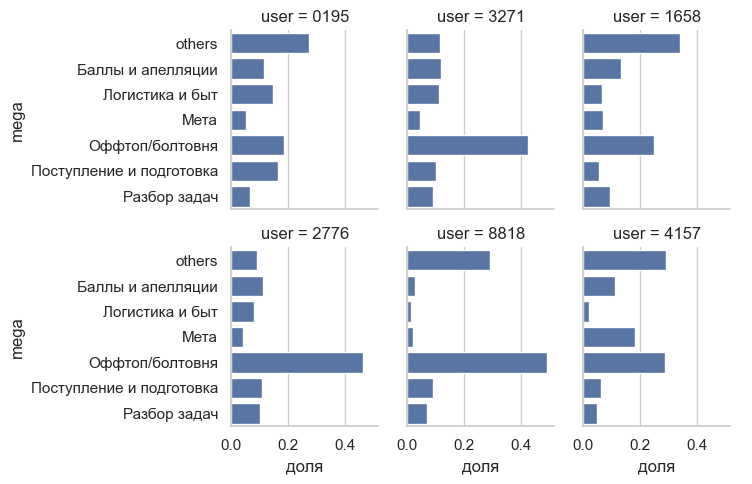

In [19]:
#анализ топ-6 активных.
act = df["author_id"].value_counts()
users = act.index[:6]

rows = []
for u in users:
    prof = df[df["author_id"] == u]["mega"].value_counts(normalize=True)
    for c in cats:
        rows.append({"user": u[-4:], "mega": c, "доля": prof.get(c, 0)})
rows = pd.DataFrame(rows)
sns.catplot(data=rows, kind="bar", y="mega", x="доля", col="user", col_wrap=3, height=2.5)

In [ ]:
#статистики сильно отличаются НО что если статистически все семплированы из одного распределения? (или это всегда будет так?)
#что тогда будет значить псевдоэргодичность если у нас есть дисперсия в траектории элемента - 
# будет ли тогда выполняться какая то оценка - 
# например траектория системы тоже близка к распределению на некую небольшую тоже погрешность
#глиномесные методы((((

+у человека сотни сообщений, а не бесконечность. шум выборки?

но есть естественная идея:

## своя половина против чужих

хитрая идея: если человек "свой" (индивидуалист, я хз как красиво назвать) - его случайная половина сообщений
похожа на вторую его половину сильнее, чем на чужого - или типа аналогично: первая половина предсказывает (или объясняет диспесию) второй половины лучше чем окружающий контекст!!!  шум выборки при этом входит в обе
стороны одинаково и сокращается.

расстояние между профилями - по хорошему использовать дивергенцию йенсена-шеннона (полусумма KL дивергенций)


как это можно сделать - достаточно активных пользователей, взять случайные N сообщений и сверить 2 распределения:
профиль тем по первым N/2 сообщениям, и по вторым N/2 сообщениям и взять k половинок других пользователей и усрединить с ними дивергенцию - то есть две половинки одного пользователя, или усреднение своя и чужая

In [27]:
#vibe code {
from scipy.spatial.distance import jensenshannon
def prof(idx):
    v = np.bincount(codes[idx], minlength=K).astype(float)
    return v / v.sum()

big = act.index[act.values >= 200]
pos = {u: np.where(df.author_id.to_numpy() == u)[0] for u in big}   

d_self, d_other = [], []
for _ in range(15):
    half = {}
    for u in big:
        s = np.random.choice(pos[u], 200, replace=False)
        half[u] = (prof(s[:100]), prof(s[100:]))
    for u in big:
        a, b = half[u]
        d_self.append(jensenshannon(a, b, base=2))
        others = np.random.choice([v for v in big if v != u], 10, replace=False)
        d_other.append(np.median([jensenshannon(a, half[v][1], base=2) for v in others]))
res = pd.DataFrame({"d": d_self + d_other,
                    "type": ["both halfs"]*len(d_self) + ["different halfs"]*len(d_other)})
#}

In [28]:
res

,d,type
0,0.139682,both halfs
1,0.123774,both halfs
2,0.118128,both halfs
3,0.198893,both halfs
4,0.161867,both halfs
...,...,...
2455,0.240588,different halfs
2456,0.453942,different halfs
2457,0.261565,different halfs
2458,0.297885,different halfs


<Axes: xlabel='d', ylabel='Density'>

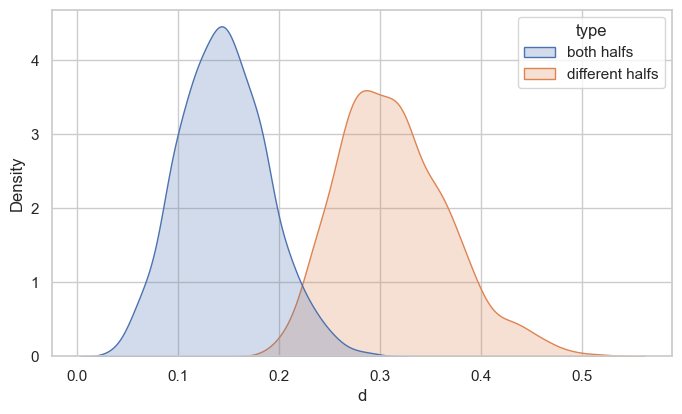

In [29]:

sns.kdeplot(x=res["d"], hue=res["type"], fill=True)

тут как то все слишком хорошо! Давайте чучуть пофиксим что половинки чужих людей были ровесниками второй половинки своей (в пределах X дней):

<Axes: xlabel='d', ylabel='Density'>

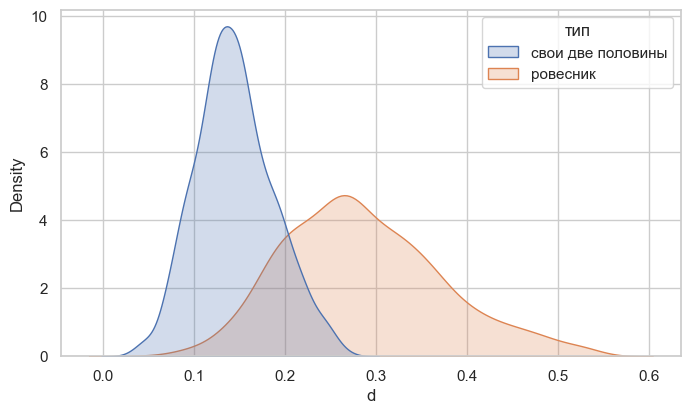

In [36]:
#vibe code {
from scipy.spatial.distance import jensenshannon
def prof(idx):
    v = np.bincount(codes[idx], minlength=K).astype(float)
    return v / v.sum()

big = act.index[act.values >= 200]
pos = {u: np.where(df.author_id.to_numpy() == u)[0] for u in big}

ts = df.ts.to_numpy().astype("datetime64[D]").astype(int)
medt = {u: np.median(ts[pos[u]]) for u in big}

d_self, d_other = [], []
for _ in range(15):
    half = {}
    for u in big:
        s = np.random.choice(pos[u], 200, replace=False)
        half[u] = (prof(s[:100]), prof(s[100:]))
    for u in big:
        a, b = half[u]
        d_self.append(jensenshannon(a, b, base=2))
        rovesniki = [v for v in big if v != u and abs(medt[v] - medt[u]) < 180]
        v = np.random.choice(rovesniki)
        d_other.append(jensenshannon(a, half[v][1], base=2))
res = pd.DataFrame({"d": d_self + d_other,
                    "тип": ["свои две половины"]*len(d_self) + ["ровесник"]*len(d_other)})
sns.kdeplot(data=res, x="d", hue="тип", fill=True, common_norm=False)
#}



In [34]:
#ну тут уже видно уже что-то - дисперсия больше, и среднее больше, то есть эффект подтверждается - люди между собой 

А что будет если проверить немного другую величину - типа насколько лучше первые N/2 сообщений предсказывают другую половину N/2 сообщений одного пользователя чем N/2 (или k * N/2) сообщений просто контекста второй половины (чужие сообщения) +нужно следить чтоб контекст был вокруг второй половины а не абы как рандомно 

можно брать также среднее по вторым половинкам только надо выбрирать чтоб они были того же времени

+как будто бы естественно использовать MSE - очевная ошибка в расхождении

<Axes: xlabel='mse', ylabel='Density'>

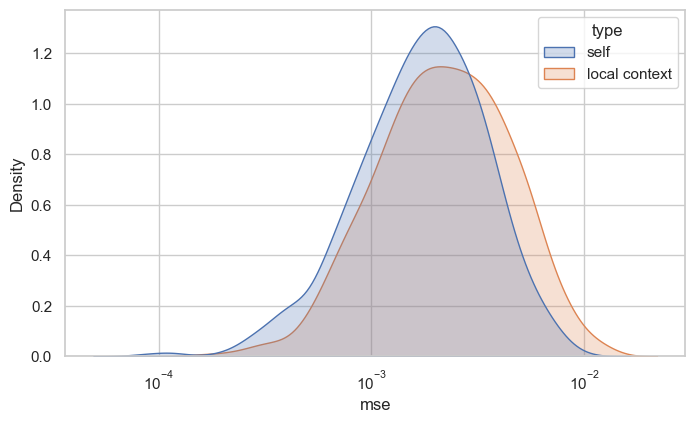

In [37]:
#vibe code {
from sklearn.metrics import mean_squared_error as mse
W = 50   # окно соседей вокруг сообщения
autr = df.author_id.to_numpy()
def local_ctx(bidx, u):
    cnt = np.zeros(K)
    for p in bidx:
        lo, hi = max(0, p-W), min(len(df), p+W+1)
        seg, sa = codes[lo:hi], autr[lo:hi]
        cnt += np.bincount(seg[sa != u], minlength=K)   # соседи, но не сам u
    return cnt / cnt.sum()

mse_self, mse_ctx = [], []
for _ in range(10):
    half = {}
    for u in big:
        s = np.random.choice(pos[u], 200, replace=False)
        half[u] = (s[:100], s[100:])       # храним индексы, не профили
    for u in big:
        aidx, bidx = half[u]
        a, b = prof(aidx), prof(bidx)
        mse_self.append(mse(b, a))
        mse_ctx.append(mse(b, local_ctx(bidx, u)))   # что творилось вокруг тех же сообщений
#}
res = pd.DataFrame({"mse": mse_self + mse_ctx,
                    "type": ["self"]*len(mse_self) + ["local context"]*len(mse_ctx)})
sns.kdeplot(data=res, x="mse", hue="type", fill=True, common_norm=False, log_scale=True)

## То есть влияние самого контекста вокруг сообщений влияет хуже чем предыдущие сообщения пользователя



что еще можно проверять???
можно взять последовательность сообщений и приписывать пачки сообщений случайным пользователям - и это считать идеальной эргодической системой, и можно ее сравнивать с реальной

можно посчитать реальное распределение тем по юзеру U и предикнутое согласно усредненной общей статистике E,

**умная мысль:** мы уже оценили MSE = (U - E)^2, но если сделать (U - E)^2 / E - то если темы редки в корпусе, то расхождение в них будет сильно штрафоваться (что-то похожее из F1 и тп идей)


Тогда можно взять такую меру разброса в реальной системе и разделить на эту меру в 100% эргодичной 

можно по разному назначать сообщения и считать эту суперстатистику - получится какое то распределение упорядоченности

In [42]:
#vibe code {
pbar = np.bincount(codes, minlength=K) / len(codes)
def phi(auth):
    u, inv = np.unique(auth, return_inverse=True)
    C = np.zeros((len(u), K))
    np.add.at(C, (inv, codes), 1)
    E = C.sum(1, keepdims=True) * pbar
    X2 = np.where(E > 0, (C - E)**2 / E, 0).sum()
    return X2 / ((len(u) - 1) * (K - 1))

auth = df.author_id.to_numpy()
real = phi(auth)

change = np.r_[True, auth[1:] != auth[:-1]]
block = np.cumsum(change) - 1
block_auth = auth[change]

nulls = []
for _ in range(200):
    nulls.append(phi(np.random.permutation(block_auth)[block]))
print(round(real, 1))

#}

9.0


<Axes: ylabel='Count'>

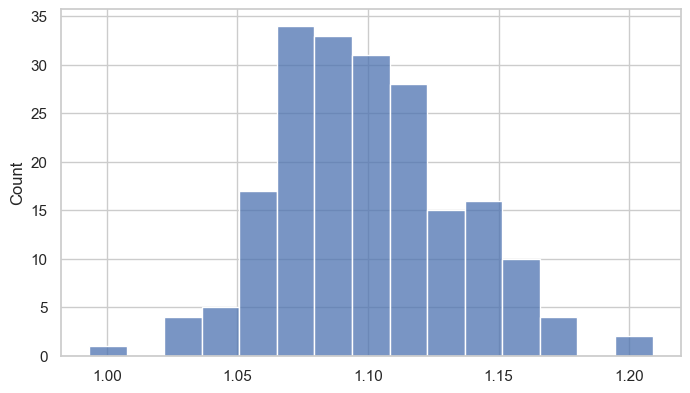

In [43]:
sns.histplot(nulls)

In [ ]:
#то есть разброс в системе в 9 раз сильнее чем в эргодической, где он примерно равен 1 
# (но это абсолютная величина, useless)

In [ ]:
#можно попробовать посмотреть на распределение самого отношения

<Axes: ylabel='Count'>

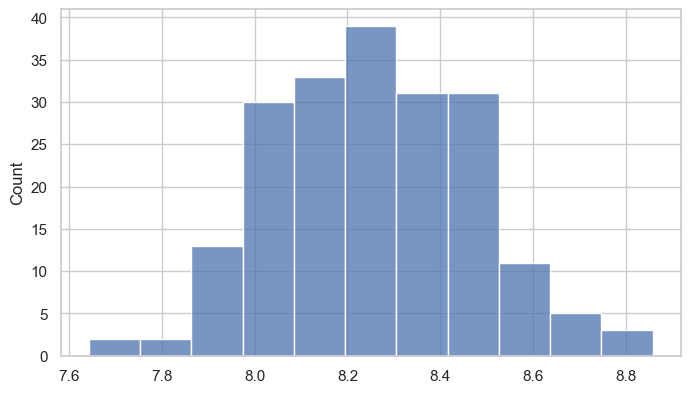

In [53]:
#vibe code{
def spread(a, cds):                       
    u, inv = np.unique(a, return_inverse=True)
    C = np.zeros((len(u), K)); np.add.at(C, (inv, cds), 1)
    E = C.sum(1, keepdims=True) * pbar
    return np.where(E > 0, (C - E)**2 / E, 0).sum()

S_real = spread(auth, codes)
S_null = np.array([spread(np.random.permutation(block_auth)[block], codes) for _ in range(200)])
phi_dist = S_real / S_null           
sns.histplot(phi_dist)
#}

In [54]:
#тут как раз видно что примерно статистика в 8 раз система более разбросана чем тн эргодическая (пермутационная) 
#мера сильно чувствительна к редким классам в добавок

## еще одна Интересная идея - траектория человека с точки зрения его времени нахождения в чате

определим величину возраста человека в чате - время с момента первого сообщения (если он много постит)

можно попробовать посмотреть как меняется распределение по темам в зависимости от возраста сообщения от пользователя - но статистика общая а не по четко людям пока проверяется!!!

<Axes: xlabel='стаж', ylabel='mega'>

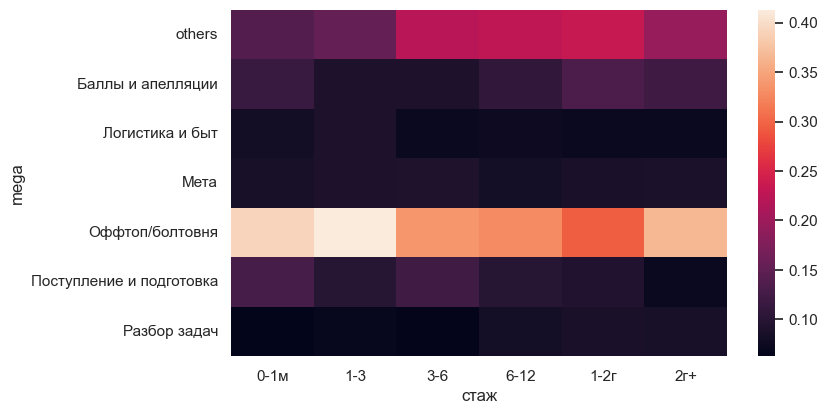

In [51]:
bins = [0, 30, 90, 180, 365, 730, 10**9]
labs = ["0-1м", "1-3", "3-6", "6-12", "1-2г", "2г+"]

df["стаж"] = pd.cut(df["tenure_days"], bins, labels=labs, right=False)

T = df.groupby("стаж", observed=True)['mega'].value_counts(normalize=True).unstack()
sns.heatmap(T[cats].T)

In [56]:
# ну тут что-то видно, определенно, но какой четко тренд сказать трудно
#видимо активность по каждой теме это нечто U-образное (вверх или вниз выпуклое это нетривиально)

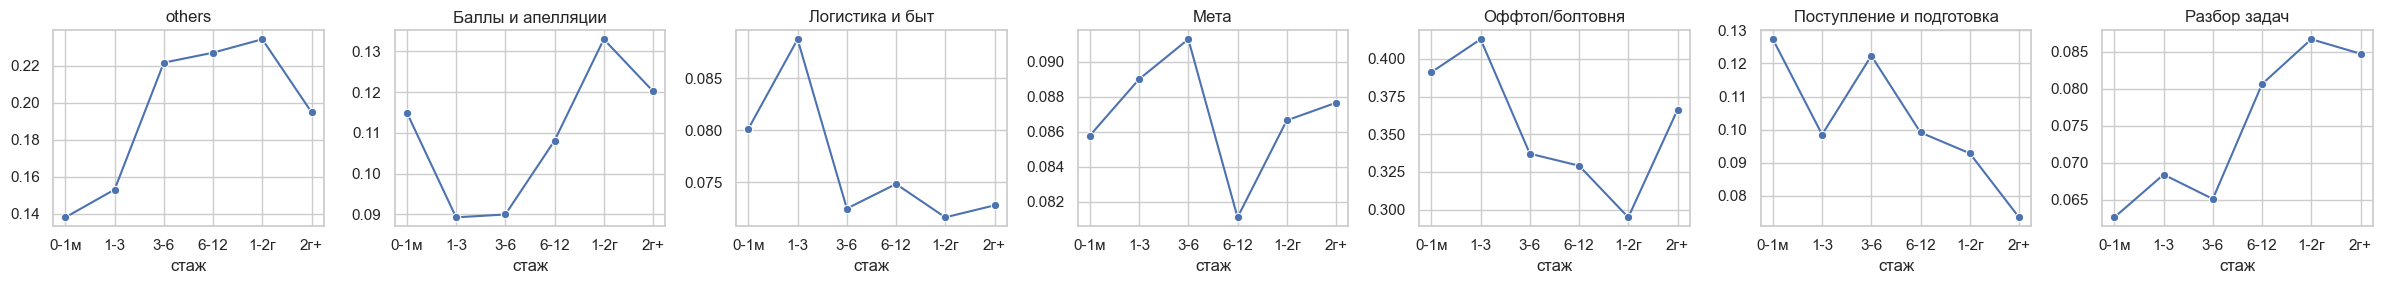

In [60]:
#gemini {

import matplotlib.pyplot as plt
# Создаем 1 строку и столько колонок, сколько у нас категорий в cats
fig, axes = plt.subplots(1, len(cats), figsize=(24, 3))

# Проходимся по каждой категории и рисуем график в соответствующей ячейке
for i, cat in enumerate(cats):
    sns.lineplot(x=T.index, y=T[cat], ax=axes[i], marker='o')
    axes[i].set_title(cat) # Добавляем название категории
    axes[i].set_ylabel('') # Убираем лишние подписи оси Y для красоты

plt.tight_layout()
plt.show()

#}

но здесь может быть тонкая лажа - олды (у кого стаж большшой) это те кто НЕ ушёл: может они не стали другими а всегда были - просто их количество и статистика меняется!!!!
Надо сравнить первые 3 месяца у тех кто прожил >=2 года и у тех кто ушёл за 3 месяца.

<Axes: xlabel='доля', ylabel='mega'>

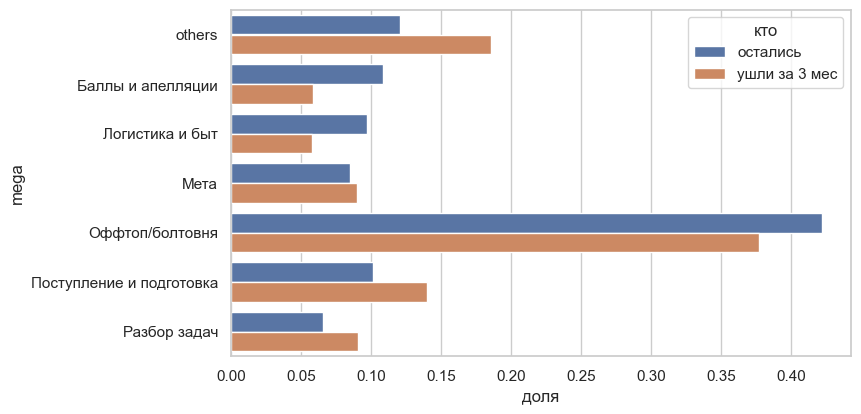

In [57]:
life = df.groupby("author_id")["tenure_days"].transform("max")
first3 = df["tenure_days"] < 90

surv = df[first3 & (life >= 730)]["mega"].value_counts(normalize=True)
chur = df[first3 & (life < 90)]["mega"].value_counts(normalize=True)

sv = pd.DataFrame({"остались": surv, "ушли за 3 мес": chur}).fillna(0)
sv = sv.rename_axis("mega").reset_index()
sv = sv.melt("mega", var_name="кто", value_name="доля")

sns.barplot(data=sv, y="mega", x="доля", hue="кто")

In [58]:
# разницы заметны (а это только первые 3 месяца!) 
# значит жизненный цикл частично это просто "отбор выживших"

## итоги по идеям

1. на коротких окнах темы гуляют в десятки раз сильнее базовой дисперсии => волны
2. люди разбросаны по темам в ~8-9 раз сильнее случайного => эргодичность нарушена; есть группы??
3. профиль едет по времени в чате, но заметная часть этого - отбор выживших

предположения по этому всему: общая статистика стоит на месте не потому что все одинаковые, а потому что разные части складываются в застывшую смесь + приток/уход в равновесии (типа потоки стабильные)
